# Customer Churn Prediction Project

## Jupyter Shortcuts

- Ctrl + Z → Undo typing  
- Esc + Z → Undo deleted cell  
- Shift + Enter → Run cell  
- A → Add cell above  
- B → Add cell below

## 1. Import Libraries

In [38]:
# Show all files inside current project folder
import os
os.listdir()
# Bring pandas so we can work with table data
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE


## 2. Load Dataset

In [2]:
# Load our churn data file into Python
df = pd.read_csv("Churn.csv")

# Show first 5 customers to see how data looks
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Data Cleaning

In [3]:
# See total rows, columns and data types
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
# Check how many rows and columns are there
df.shape


(7043, 21)

In [5]:
# Check how many customers stayed and left
df["Churn"].value_counts()


Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [6]:
# Count missing values in each column
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:

# Checking data types of all columns
df.dtypes


customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

## 4.Data Preprocessing

In [8]:
# Remove ID column (not useful for prediction)
df.drop("customerID", axis=1, inplace=True, errors="ignore")
print(df.columns)


Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [9]:
# Convert TotalCharges to numeric (text → number)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')
print(df["TotalCharges"].dtype)



float64


In [10]:
# Replace missing values with median
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())
print(df["TotalCharges"].isnull().sum())



0


## 5. Encoding Categorical Variables

In [11]:
# Convert target variable to 0 and 1
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Label encode other categorical columns
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])


## 6.Feature Selection

In [27]:
# X = input features, y = target; drop 'Churn' from X to avoid data leakage
X = df.drop('Churn', axis=1)
y = df['Churn']


In [28]:
# Scale features so all values have mean=0 and std=1 for better model performance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


## 7.Split Data

In [29]:
# Split data: 80% train, 20% test to evaluate model on unseen data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [39]:
# Apply SMOTE (to balance data)
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

## 8.Train Model

In [30]:
# Teach the Random Forest model to learn patterns from training data
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 9. Predictions

In [31]:
# Predict churn for test data using the trained model
y_pred = model.predict(X_test)

In [44]:
# Retrain Random Forest using balanced class weight to handle churn imbalance
# Stronger RandomForest
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight={0:1,1:2},  # Give more importance to churn
    random_state=42
)

model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Results
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))



Accuracy: 0.751596877217885

Confusion Matrix:
 [[749 287]
 [ 63 310]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.72      0.81      1036
           1       0.52      0.83      0.64       373

    accuracy                           0.75      1409
   macro avg       0.72      0.78      0.72      1409
weighted avg       0.82      0.75      0.77      1409



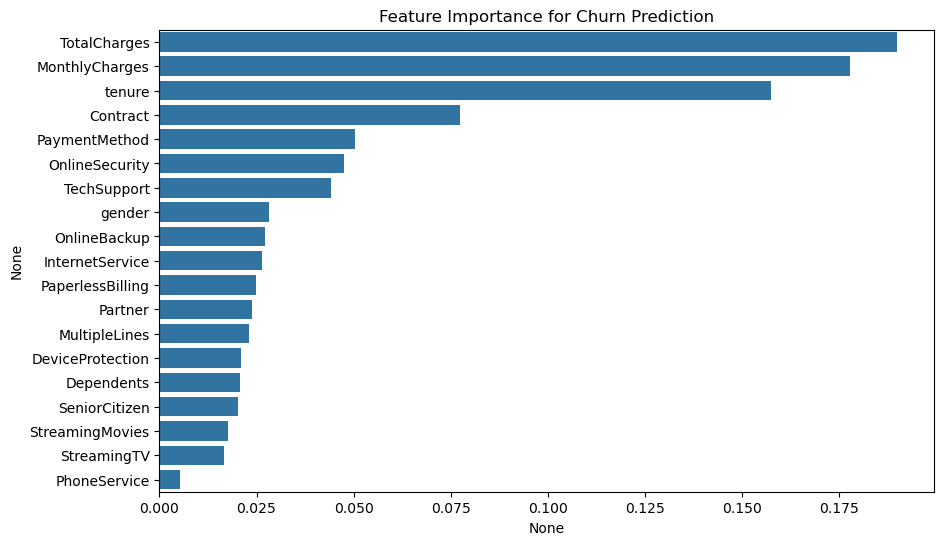

In [32]:
# Feature importance shows which features most influence the model's churn predictions
# Helps understand model decisions and guides business actions
# Get feature importance from the trained model
feature_importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

# Plot feature importance
plt.figure(figsize=(10,6))
sns.barplot(x=feature_importances, y=feature_importances.index)
plt.title("Feature Importance for Churn Prediction")
plt.show()

In [45]:
print(feature_importances.head(5))


TotalCharges      0.189992
MonthlyCharges    0.177867
tenure            0.157428
Contract          0.077357
PaymentMethod     0.050379
dtype: float64
